In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Funciones de convolucion direccional 

def filtro_diagonal(img, tam):
    """Aplica convolucion con kernel diagonal principal"""
    k = np.zeros((tam, tam), dtype=np.float32)
    np.fill_diagonal(k, 1.0)
    k /= tam
    resultado = cv2.filter2D(img.astype(np.float32), -1, k)
    return np.clip(resultado, 0, 255).astype(np.uint8)

def filtro_diagonal_inv(img, tam):
    """Aplica convolucion con kernel anti-diagonal"""
    k = np.zeros((tam, tam), dtype=np.float32)
    for j in range(tam):
        k[j, tam - 1 - j] = 1.0
    k /= tam
    resultado = cv2.filter2D(img.astype(np.float32), -1, k)
    return np.clip(resultado, 0, 255).astype(np.uint8)

def crear_patron_franjas(ancho, alto, frecuencia=20, angulo=0):
    """Genera un patron de franjas con orientacion y frecuencia dadas"""
    cx = np.linspace(-np.pi, np.pi, ancho)
    cy = np.linspace(-np.pi, np.pi, alto)
    gx, gy = np.meshgrid(cx, cy)
    rad = np.deg2rad(angulo)
    rotado = gx * np.cos(rad) + gy * np.sin(rad)
    franjas = 0.5 + 0.5 * np.sign(np.sin(frecuencia * rotado))
    return cv2.GaussianBlur((franjas * 255).astype(np.uint8), (3, 3), 0)

def crear_moire(ancho, alto, f1=40, f2=42, a1=0, a2=5):
    """Superpone dos patrones de franjas para generar efecto Moire"""
    p1 = crear_patron_franjas(ancho, alto, f1, a1)
    p2 = crear_patron_franjas(ancho, alto, f2, a2)
    return cv2.addWeighted(p1, 0.5, p2, 0.5, 0)

def mezclar_patron(img_gris, patron, intensidad=0.45):
    """Superpone un patron sobre una imagen en escala de grises"""
    return cv2.addWeighted(img_gris, 1.0 - intensidad, patron, intensidad, 0)

def reducir_escala(img_gris, factor=0.25, suavizar=False, tam_blur=5):
    """Reduce la imagen, opcionalmente con pre-blur anti-aliasing"""
    if suavizar:
        img_gris = cv2.GaussianBlur(img_gris, (tam_blur, tam_blur), 0)
    alto, ancho = img_gris.shape[:2]
    return cv2.resize(img_gris, (int(ancho * factor), int(alto * factor)), interpolation=cv2.INTER_AREA)

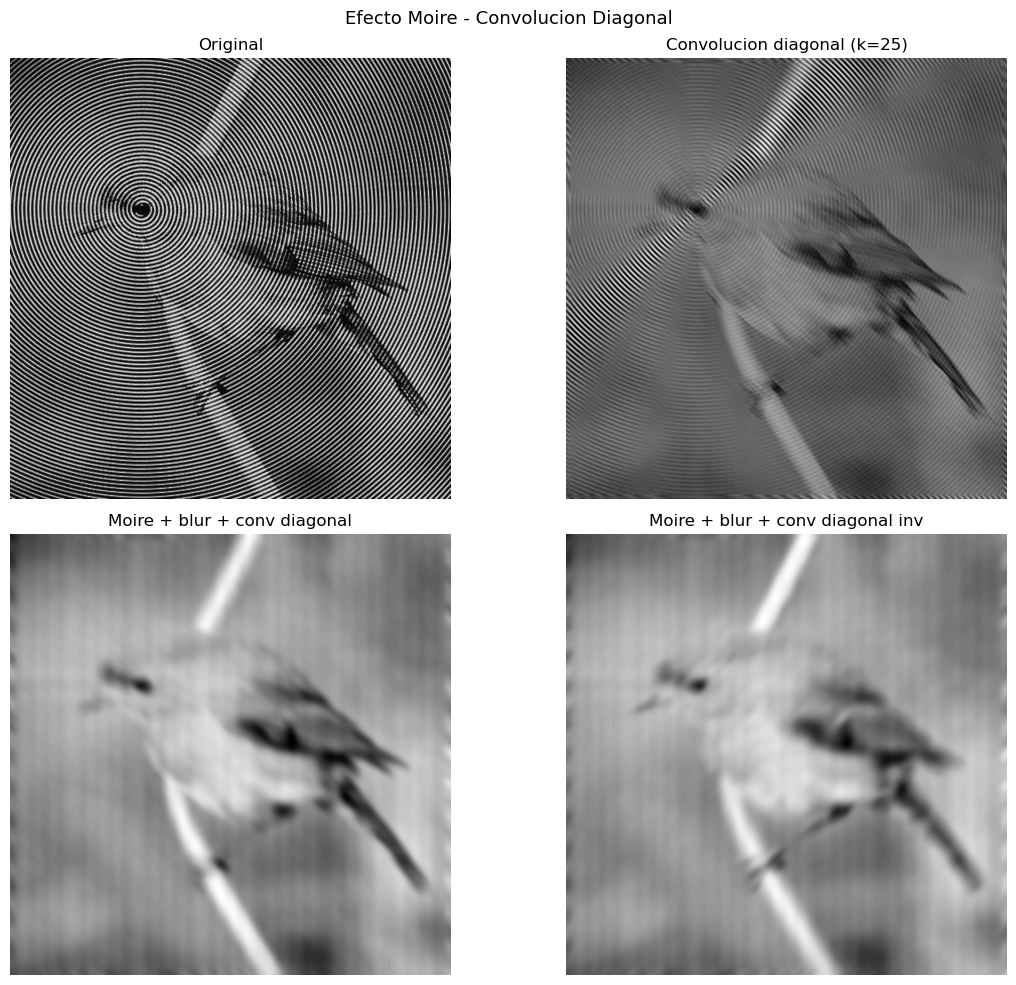

In [3]:
# Moire y convolucion 

foto_moire = cv2.imread('Moire.png', 0)
alto_m, ancho_m = foto_moire.shape

# Parametros
t_kernel = 25
mezcla = 0.5
frec_a, frec_b = 95, 98
ang_a, ang_b = 0, 8
blur_previo = 45

# superponer
patron_m = crear_moire(ancho_m, alto_m, f1=frec_a, f2=frec_b, a1=ang_a, a2=ang_b)
foto_con_moire = mezclar_patron(foto_moire, patron_m, intensidad=mezcla)

# Suavizado + convolucion
if blur_previo % 2 == 0:
    blur_previo += 1
foto_blur = cv2.GaussianBlur(foto_con_moire, (blur_previo, blur_previo), 0)
foto_corregida = filtro_diagonal(foto_blur, t_kernel)

foto_corregida_inv = filtro_diagonal_inv(foto_blur, t_kernel)

fig, ejes = plt.subplots(2, 2, figsize=(12, 10))

ejes[0, 0].imshow(foto_moire, cmap='gray')
ejes[0, 0].set_title('Original')
ejes[0, 0].axis('off')

ejes[0, 1].imshow(filtro_diagonal(foto_moire, t_kernel), cmap='gray')
ejes[0, 1].set_title('Convolucion diagonal (k={})'.format(t_kernel))
ejes[0, 1].axis('off')

ejes[1, 0].imshow(foto_corregida, cmap='gray')
ejes[1, 0].set_title('Moire + blur + conv diagonal')
ejes[1, 0].axis('off')

ejes[1, 1].imshow(foto_corregida_inv, cmap='gray')
ejes[1, 1].set_title('Moire + blur + conv diagonal inv')
ejes[1, 1].axis('off')

plt.suptitle('Efecto Moire - Convolucion Diagonal', fontsize=13)
plt.tight_layout()
plt.show()

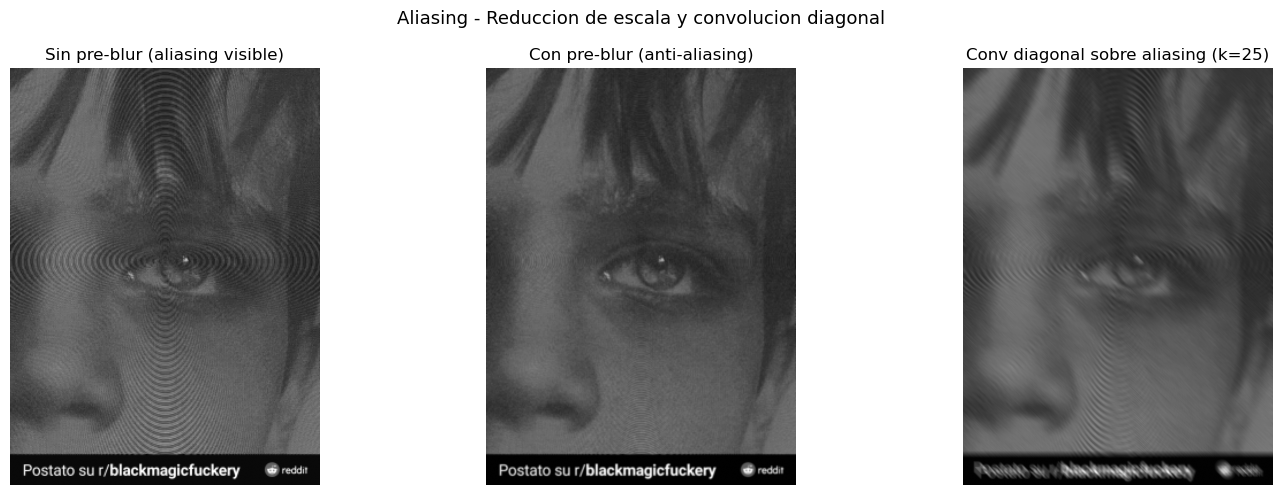

In [4]:
# Aliasing y reduccion

foto_alias = cv2.imread('Aliasing.png', 0)
alto_a, ancho_a = foto_alias.shape

escala = 0.25
tam_suavizado = 7

# Sin pre-blur
reducida_cruda = reducir_escala(foto_alias, factor=escala, suavizar=False)
# Con pre-blur
reducida_suave = reducir_escala(foto_alias, factor=escala, suavizar=True, tam_blur=tam_suavizado)

# Escalar de vuelta para visualizar
vista_cruda = cv2.resize(reducida_cruda, (ancho_a, alto_a), interpolation=cv2.INTER_NEAREST)
vista_suave = cv2.resize(reducida_suave, (ancho_a, alto_a), interpolation=cv2.INTER_NEAREST)

# Aplicar convolucion diagonal sobre la version con aliasing
vista_diag = filtro_diagonal(vista_cruda, t_kernel)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

ejes[0].imshow(vista_cruda, cmap='gray')
ejes[0].set_title('Sin pre-blur (aliasing visible)')
ejes[0].axis('off')

ejes[1].imshow(vista_suave, cmap='gray')
ejes[1].set_title('Con pre-blur (anti-aliasing)')
ejes[1].axis('off')

ejes[2].imshow(vista_diag, cmap='gray')
ejes[2].set_title('Conv diagonal sobre aliasing (k={})'.format(t_kernel))
ejes[2].axis('off')

plt.suptitle('Aliasing - Reduccion de escala y convolucion diagonal', fontsize=13)
plt.tight_layout()
plt.show()